# Analiza produkcji Netflix Originals i ocen IMDb

Celem notebooka jest uporządkowana analiza danych o produkcjach Netflix Originals. Notebook zachowuje dotychczasową logikę pracy: wczytanie danych, czyszczenie, eksplorację danych, wizualizacje oraz podstawową analizę statystyczną.

Projekt skupia się na odpowiedzi na pytania: jakie gatunki i języki dominują w katalogu, jak rozkładają się oceny IMDb, czy czas trwania filmu ma związek z oceną oraz które produkcje i gatunki wypadają najlepiej.


## Pytania badawcze

1. Jakie gatunki występują najczęściej w zbiorze Netflix Originals?
2. Jakie języki dominują wśród produkcji Netflix Originals?
3. Jak wygląda rozkład czasu trwania produkcji?
4. Jak wygląda rozkład ocen IMDb i czy występują produkcje skrajnie wysoko lub nisko oceniane?
5. Które gatunki oraz filmy mają najwyższe średnie oceny IMDb?


## 1. Import bibliotek i wczytanie danych

W tej części importujemy biblioteki potrzebne do analizy danych, wizualizacji oraz metod statystycznych. Następnie wczytujemy plik `NetflixOriginals.csv`.


In [1]:
# Biblioteki do pracy z danymi
import numpy as np
import pandas as pd

# Biblioteki do wizualizacji
import matplotlib.pyplot as plt
import seaborn as sns

# Metody statystyczne
from scipy.stats import pearsonr, f_oneway

# Ustawienie stylu wykresów
sns.set_theme(style="whitegrid")

# Wczytanie danych z pliku CSV
# Plik powinien znajdować się w tym samym folderze co notebook.
data = pd.read_csv("NetflixOriginals.csv", encoding='latin-1')


In [2]:
# Podgląd pierwszych wierszy danych
display(data.head())


,Title,Genre,Premiere,Runtime,IMDB Score,Language
0,Enter the Anime,Documentary,"August 5, 2019",58,2.5,English/Japanese
1,Dark Forces,Thriller,"August 21, 2020",81,2.6,Spanish
2,The App,Science fiction/Drama,"December 26, 2019",79,2.6,Italian
3,The Open House,Horror thriller,"January 19, 2018",94,3.2,English
4,Kaali Khuhi,Mystery,"October 30, 2020",90,3.4,Hindi


In [3]:
# Informacje o liczbie wierszy, kolumnach, typach danych i brakach
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584 entries, 0 to 583
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Title       584 non-null    object 
 1   Genre       584 non-null    object 
 2   Premiere    584 non-null    object 
 3   Runtime     584 non-null    int64  
 4   IMDB Score  584 non-null    float64
 5   Language    584 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 27.5+ KB


In [4]:
# Podstawowe statystyki dla kolumn liczbowych
display(data.describe())


,Runtime,IMDB Score
count,584.000000,584.000000
mean,93.577055,6.271747
std,27.761683,0.979256
min,4.000000,2.500000
25%,86.000000,5.700000
50%,97.000000,6.350000
75%,108.000000,7.000000
max,209.000000,9.000000


In [5]:
# Lista kolumn w zbiorze danych
print(data.columns.tolist())


['Title', 'Genre', 'Premiere', 'Runtime', 'IMDB Score', 'Language']


## 2. Sprawdzenie braków danych i przygotowanie daty

Najpierw sprawdzamy, czy w danych występują braki. Następnie kolumna `Premiere` jest zamieniana na typ daty, aby można było analizować rok, miesiąc oraz dzień premiery.


In [6]:
# Liczba braków danych w każdej kolumnie
missing_values = data.isnull().sum()
display(missing_values[missing_values > 0])


Series([], dtype: int64)

In [7]:
# Czyszczenie formatu daty.
# W niektórych rekordach może pojawić się kropka zamiast przecinka, np. "October 16. 2019".
data["Premiere_clean"] = data["Premiere"].astype(str).str.replace(
    r"([A-Za-z]+ \d{1,2})\. (\d{4})",
    r", ",
    regex=True
)

# Zamiana tekstu na format daty.
# errors='coerce' zamieni błędne daty na NaT zamiast przerywać działanie notebooka.
data["date"] = pd.to_datetime(data["Premiere_clean"], errors="coerce")

# Kontrola, czy jakaś data nie została poprawnie odczytana.
display(data.loc[data["date"].isna(), ["Title", "Premiere"]])


,Title,Premiere
111,Ghosts of Sugar Land,October 16. 2019
308,Strong Island,September 15. 2017
387,Tony Robbins: I Am Not Your Guru,July 15. 2016
538,Joan Didion: The Center Will Not Hold,October 27. 2017
541,The White Helmets,September 16. 2016


In [8]:
# Utworzenie nowych kolumn czasowych do dalszej analizy
data['year_month'] = data['date'].dt.strftime('%Y-%m')
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.dayofweek

# Podgląd danych po dodaniu kolumn czasowych
display(data.head())


,Title,Genre,Premiere,Runtime,IMDB Score,Language,Premiere_clean,date,year_month,year,month,day
0,Enter the Anime,Documentary,"August 5, 2019",58,2.5,English/Japanese,"August 5, 2019",2019-08-05,2019-08,2019.0,8.0,0.0
1,Dark Forces,Thriller,"August 21, 2020",81,2.6,Spanish,"August 21, 2020",2020-08-21,2020-08,2020.0,8.0,4.0
2,The App,Science fiction/Drama,"December 26, 2019",79,2.6,Italian,"December 26, 2019",2019-12-26,2019-12,2019.0,12.0,3.0
3,The Open House,Horror thriller,"January 19, 2018",94,3.2,English,"January 19, 2018",2018-01-19,2018-01,2018.0,1.0,4.0
4,Kaali Khuhi,Mystery,"October 30, 2020",90,3.4,Hindi,"October 30, 2020",2020-10-30,2020-10,2020.0,10.0,4.0


## 3. Analiza gatunków i języków

W tej części sprawdzamy, jakie gatunki oraz języki pojawiają się najczęściej w zbiorze danych.


In [9]:
# Liczba unikalnych gatunków
gen = data["Genre"].nunique()
print("Liczba unikalnych gatunków:", gen)

# Procentowy udział poszczególnych gatunków
display(data["Genre"].value_counts(normalize=True).head(10) * 100)


Liczba unikalnych gatunków: 115


Genre
Documentary        27.226027
Drama              13.184932
Comedy              8.390411
Romantic comedy     6.678082
Thriller            5.650685
Comedy-drama        2.397260
Crime drama         1.883562
Biopic              1.541096
Horror              1.541096
Action              1.198630
Name: proportion, dtype: float64

Genre
Documentary        159
Drama               77
Comedy              49
Romantic comedy     39
Thriller            33
Comedy-drama        14
Crime drama         11
Biopic               9
Horror               9
Action               7
Name: count, dtype: int64

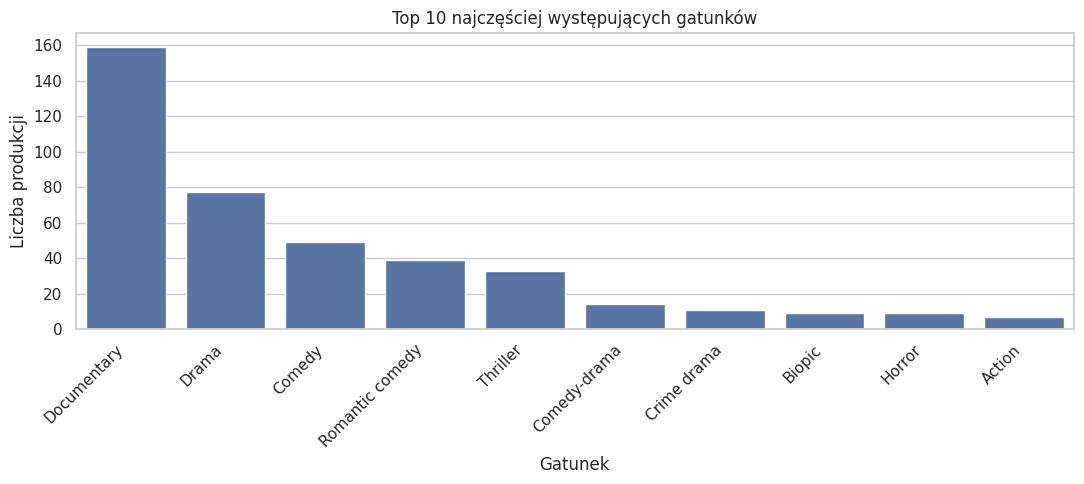

In [10]:
# 10 najczęściej występujących gatunków
genre_top10 = data['Genre'].value_counts().head(10)
display(genre_top10)

plt.figure(figsize=(11, 5))
sns.barplot(x=genre_top10.index, y=genre_top10.values)

plt.title("Top 10 najczęściej występujących gatunków")
plt.xlabel("Gatunek")
plt.ylabel("Liczba produkcji")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Liczba unikalnych języków: 38


Language
English       401
Hindi          33
Spanish        31
French         20
Italian        14
Portuguese     12
Indonesian      9
Japanese        6
Korean          6
German          5
Name: count, dtype: int64

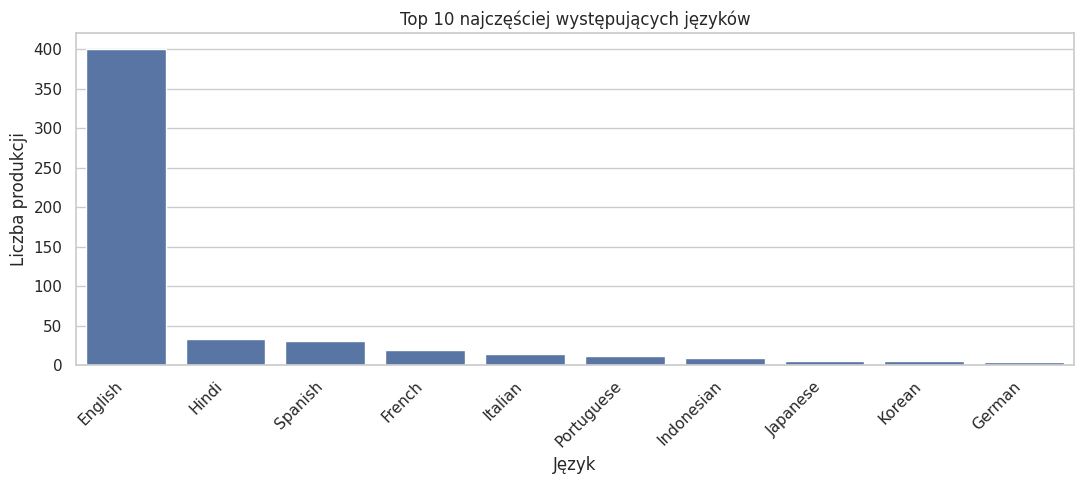

In [11]:
# Liczba unikalnych języków
lang = data['Language'].nunique()
print("Liczba unikalnych języków:", lang)

# 10 najczęściej występujących języków
lang_top10 = data['Language'].value_counts().head(10)
display(lang_top10)

plt.figure(figsize=(11, 5))
sns.barplot(x=lang_top10.index, y=lang_top10.values)

plt.title("Top 10 najczęściej występujących języków")
plt.xlabel("Język")
plt.ylabel("Liczba produkcji")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 4. Analiza czasu trwania produkcji

Sprawdzamy podstawowe statystyki kolumny `Runtime`, a następnie pokazujemy rozkład czasu trwania na histogramie oraz wykresie pudełkowym.


In [12]:
# Statystyki opisowe czasu trwania produkcji
display(data['Runtime'].describe())


count    584.000000
mean      93.577055
std       27.761683
min        4.000000
25%       86.000000
50%       97.000000
75%      108.000000
max      209.000000
Name: Runtime, dtype: float64

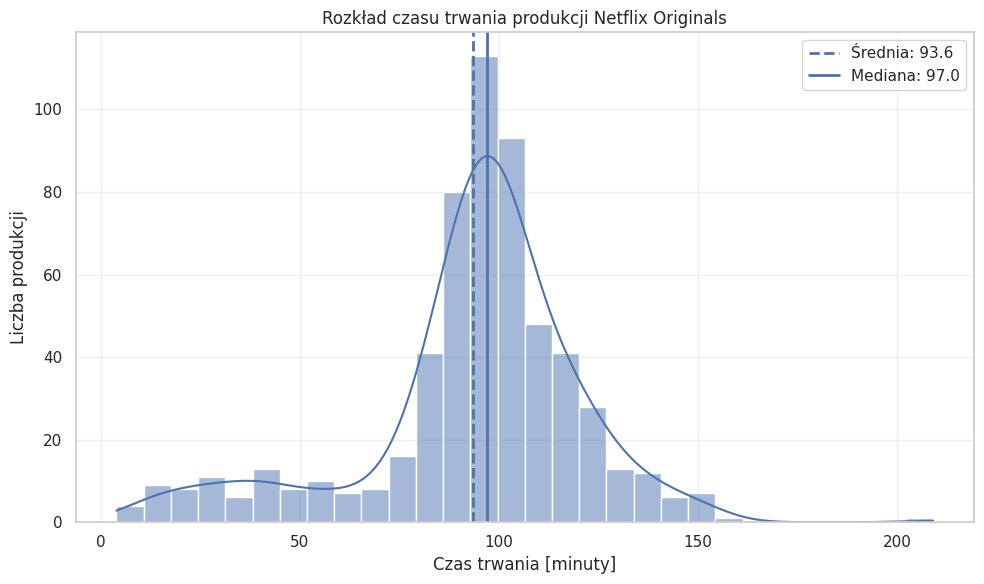

In [13]:
# Średnia i mediana czasu trwania
srednia_runtime = data['Runtime'].mean()
mediana_runtime = data['Runtime'].median()

plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='Runtime', bins=30, kde=True)

# Linie pionowe pokazują średnią i medianę
plt.axvline(srednia_runtime, linestyle='--', linewidth=2, label=f'Średnia: {srednia_runtime:.1f}')
plt.axvline(mediana_runtime, linestyle='-', linewidth=2, label=f'Mediana: {mediana_runtime:.1f}')

plt.title('Rozkład czasu trwania produkcji Netflix Originals')
plt.xlabel('Czas trwania [minuty]')
plt.ylabel('Liczba produkcji')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


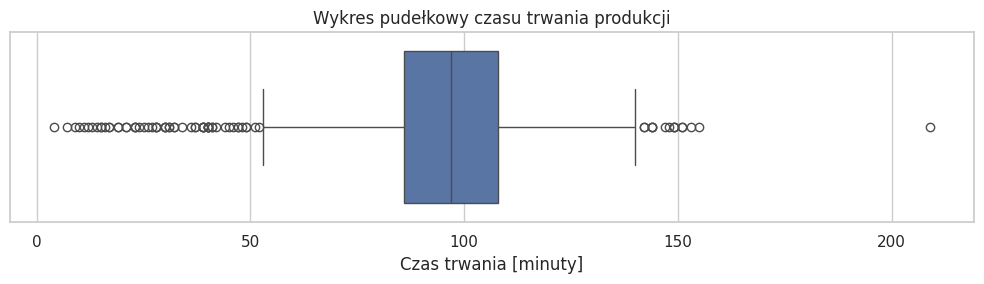

In [14]:
# Wykres pudełkowy pomaga wykryć wartości odstające w czasie trwania produkcji.
plt.figure(figsize=(10, 3))
sns.boxplot(data=data, x='Runtime')

plt.title('Wykres pudełkowy czasu trwania produkcji')
plt.xlabel('Czas trwania [minuty]')
plt.tight_layout()
plt.show()


## 5. Analiza ocen IMDb

W tej części analizujemy rozkład ocen IMDb oraz produkcje o skrajnie wysokich lub niskich ocenach.


In [15]:
# Statystyki opisowe ocen IMDb
display(data["IMDB Score"].describe())


count    584.000000
mean       6.271747
std        0.979256
min        2.500000
25%        5.700000
50%        6.350000
75%        7.000000
max        9.000000
Name: IMDB Score, dtype: float64

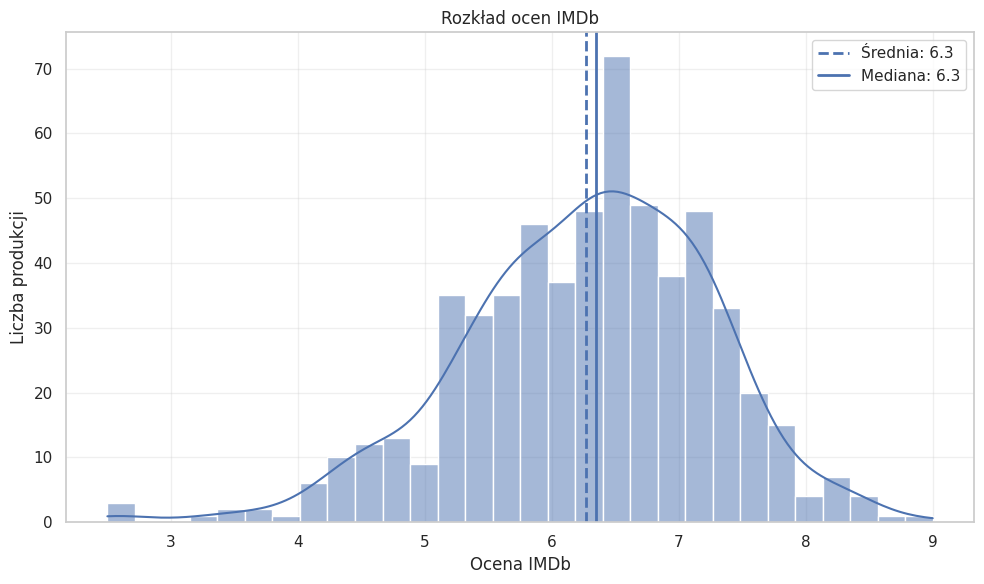

In [16]:
# Średnia i mediana ocen IMDb
srednia_imdb = data['IMDB Score'].mean()
mediana_imdb = data['IMDB Score'].median()

plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='IMDB Score', bins=30, kde=True)

# Linie pionowe pokazują średnią i medianę
plt.axvline(srednia_imdb, linestyle='--', linewidth=2, label=f'Średnia: {srednia_imdb:.1f}')
plt.axvline(mediana_imdb, linestyle='-', linewidth=2, label=f'Mediana: {mediana_imdb:.1f}')

plt.title('Rozkład ocen IMDb')
plt.xlabel('Ocena IMDb')
plt.ylabel('Liczba produkcji')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


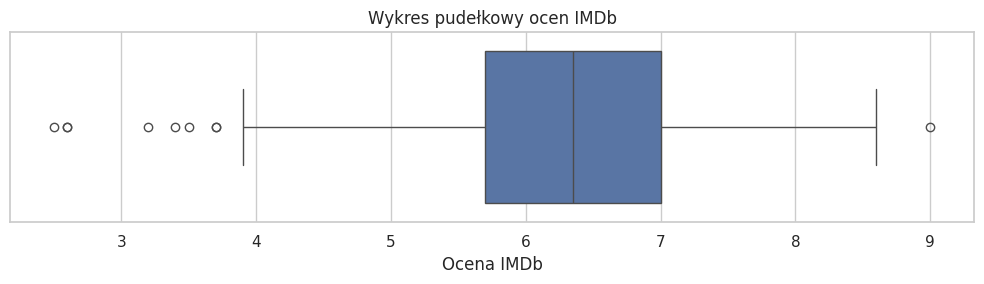

In [17]:
# Wykres pudełkowy ocen IMDb pokazuje medianę, kwartyle oraz potencjalne wartości odstające.
plt.figure(figsize=(10, 3))
sns.boxplot(data=data, x='IMDB Score')

plt.title('Wykres pudełkowy ocen IMDb')
plt.xlabel('Ocena IMDb')
plt.tight_layout()
plt.show()


In [18]:
# Produkcje skrajne: bardzo wysoko ocenione oraz bardzo nisko ocenione.
extreme_scores = data[(data["IMDB Score"] > 8.8) | (data["IMDB Score"] < 4)]
display(extreme_scores[["Title", "Genre", "Language", "Runtime", "IMDB Score"]])


,Title,Genre,Language,Runtime,IMDB Score
0,Enter the Anime,Documentary,English/Japanese,58,2.5
1,Dark Forces,Thriller,Spanish,81,2.6
2,The App,Science fiction/Drama,Italian,79,2.6
3,The Open House,Horror thriller,English,94,3.2
4,Kaali Khuhi,Mystery,Hindi,90,3.4
5,Drive,Action,Hindi,147,3.5
6,Leyla Everlasting,Comedy,Turkish,112,3.7
7,The Last Days of American Crime,Heist film/Thriller,English,149,3.7
8,Paradox,Musical/Western/Fantasy,English,73,3.9
583,David Attenborough: A Life on Our Planet,Documentary,English,83,9.0


## 6. Zależność między czasem trwania a oceną IMDb

Sprawdzamy, czy dłuższe produkcje mają tendencję do uzyskiwania wyższych lub niższych ocen IMDb.


In [19]:
# Macierz korelacji dla czasu trwania i oceny IMDb
runtime_scores_corr = data[['Runtime', 'IMDB Score']].corr()
display(runtime_scores_corr)


,Runtime,IMDB Score
Runtime,1.000000,-0.040896
IMDB Score,-0.040896,1.000000


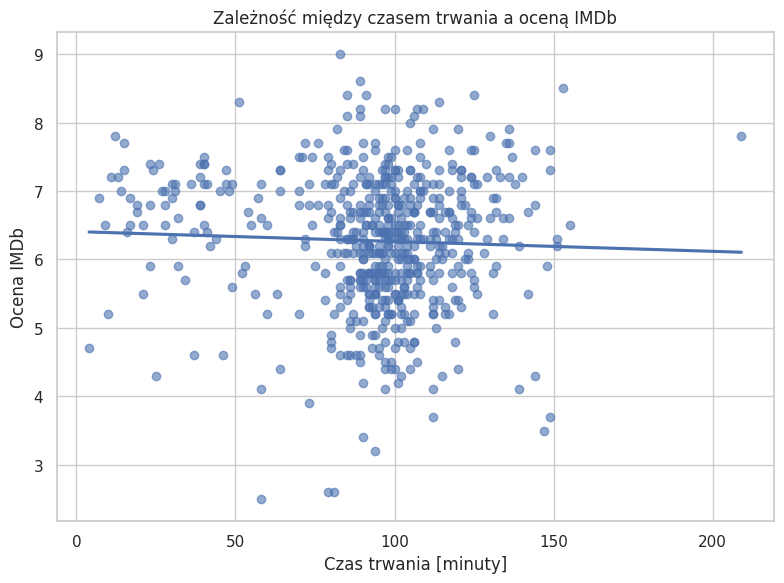

In [20]:
# Wykres punktowy z linią regresji pokazuje zależność między Runtime i IMDB Score.
plt.figure(figsize=(8, 6))
sns.regplot(
    data=data,
    x='Runtime',
    y='IMDB Score',
    ci=None,
    scatter_kws={'alpha': 0.6}
)

plt.title('Zależność między czasem trwania a oceną IMDb')
plt.xlabel('Czas trwania [minuty]')
plt.ylabel('Ocena IMDb')
plt.tight_layout()
plt.show()


## 7. Metody statystyczne

Aby odpowiedzieć na pytania badawcze nie tylko wizualnie, ale także liczbowo, wykorzystujemy korelację Pearsona oraz test ANOVA.


In [21]:
# Korelacja Pearsona: Runtime vs IMDB Score
# Test sprawdza siłę liniowej zależności między czasem trwania a oceną IMDb.
valid_runtime = data[['Runtime', 'IMDB Score']].dropna()
pearson_corr, pearson_pvalue = pearsonr(valid_runtime['Runtime'], valid_runtime['IMDB Score'])

print(f"Korelacja Pearsona Runtime vs IMDB Score: {pearson_corr:.3f}")
print(f"p-value: {pearson_pvalue:.5f}")


Korelacja Pearsona Runtime vs IMDB Score: -0.041
p-value: 0.32384


In [22]:
# ANOVA: sprawdzamy, czy średnie oceny IMDb różnią się między gatunkami.
# Aby uniknąć bardzo małych grup, bierzemy tylko gatunki z minimum 3 produkcjami.
genre_counts = data['Genre'].value_counts()
valid_genres = genre_counts[genre_counts >= 3].index

anova_data = data[data['Genre'].isin(valid_genres)].dropna(subset=['Genre', 'IMDB Score'])
groups = [group['IMDB Score'].values for _, group in anova_data.groupby('Genre')]

if len(groups) > 1:
    anova_stat, anova_pvalue = f_oneway(*groups)
    print(f"ANOVA statistic: {anova_stat:.3f}")
    print(f"p-value: {anova_pvalue:.5f}")
else:
    print("Za mało grup do wykonania testu ANOVA.")


ANOVA statistic: 10.692
p-value: 0.00000


## 8. Analiza produkcji w czasie

Sprawdzamy, w których latach pojawiało się najwięcej produkcji Netflix Originals.


year
2014.0      1
2015.0      9
2016.0     28
2017.0     64
2018.0     99
2019.0    124
2020.0    183
2021.0     71
Name: count, dtype: int64

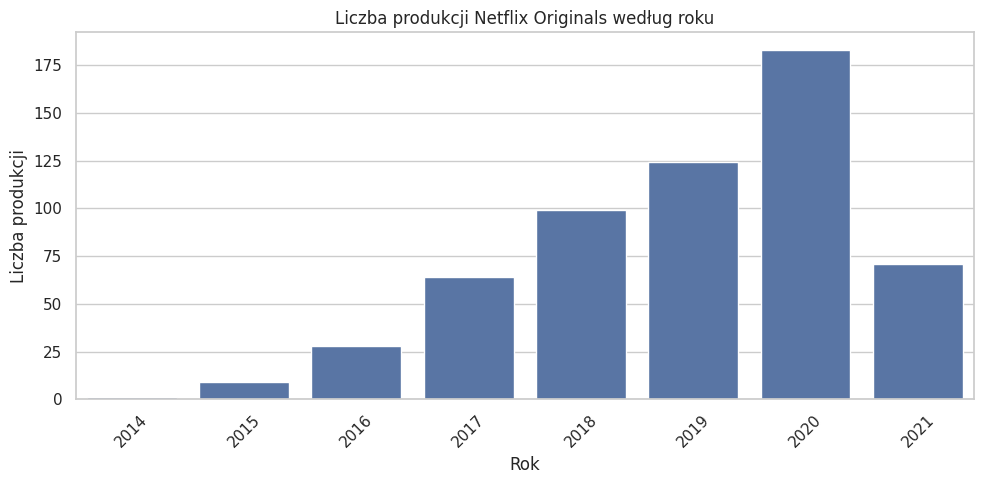

In [23]:
# Liczba produkcji w poszczególnych latach
year = data['year'].value_counts().sort_index()
display(year)

plt.figure(figsize=(10, 5))
sns.barplot(x=year.index.astype(int), y=year.values)

plt.title('Liczba produkcji Netflix Originals według roku')
plt.xlabel('Rok')
plt.ylabel('Liczba produkcji')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 9. Najwyżej oceniane gatunki

Liczymy średnią ocenę IMDb dla każdego gatunku. Warto pamiętać, że wynik może być zawyżony dla gatunków, które mają bardzo mało produkcji.


Genre
Animation/Christmas/Comedy/Adventure    8.200000
Musical / Short                         7.700000
Concert Film                            7.633333
Anthology/Dark comedy                   7.600000
Animation / Science Fiction             7.500000
Making-of                               7.450000
Action-adventure                        7.300000
Historical drama                        7.200000
Coming-of-age comedy-drama              7.200000
Drama-Comedy                            7.200000
Name: IMDB Score, dtype: float64

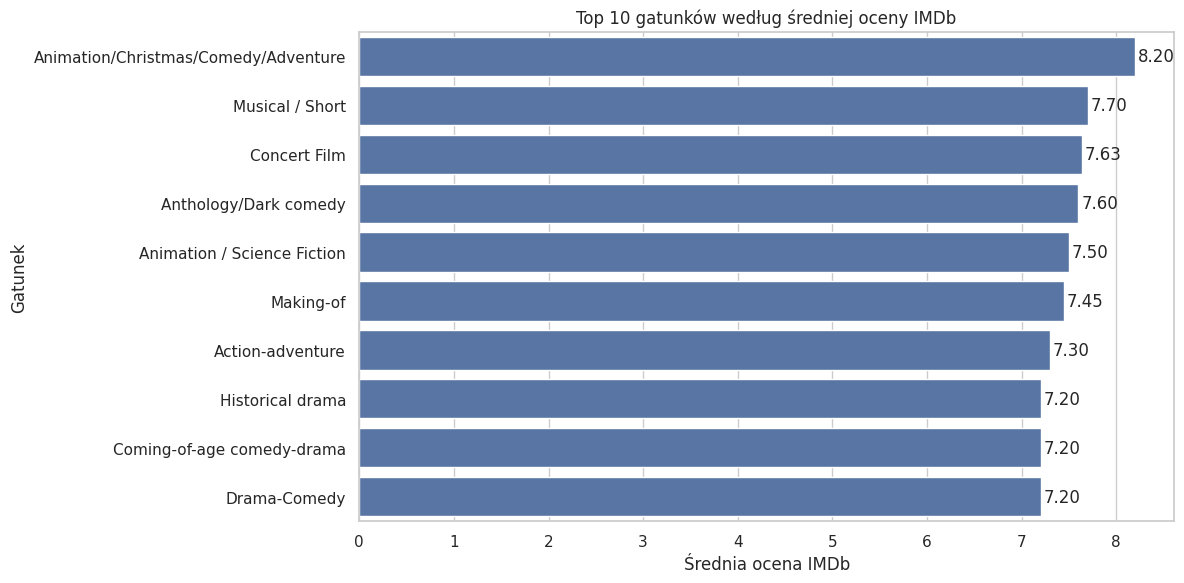

In [24]:
# Top 10 gatunków według średniej oceny IMDb
top_10_rating_bygenre = (
    data.groupby('Genre')['IMDB Score']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

display(top_10_rating_bygenre)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_10_rating_bygenre.values, y=top_10_rating_bygenre.index)

plt.title('Top 10 gatunków według średniej oceny IMDb')
plt.xlabel('Średnia ocena IMDb')
plt.ylabel('Gatunek')

for i, value in enumerate(top_10_rating_bygenre.values):
    ax.text(value + 0.03, i, f'{value:.2f}', va='center')

plt.tight_layout()
plt.show()


,avg_score,movie_count
Genre,,
Concert Film,7.633333,6
One-man show,7.133333,3
Animation / Short,7.125000,4
Documentary,6.936478,159
Aftershow / Interview,6.750000,6
Crime drama,6.745455,11
Animation,6.560000,5
Romance,6.500000,6
Psychological thriller,6.500000,4


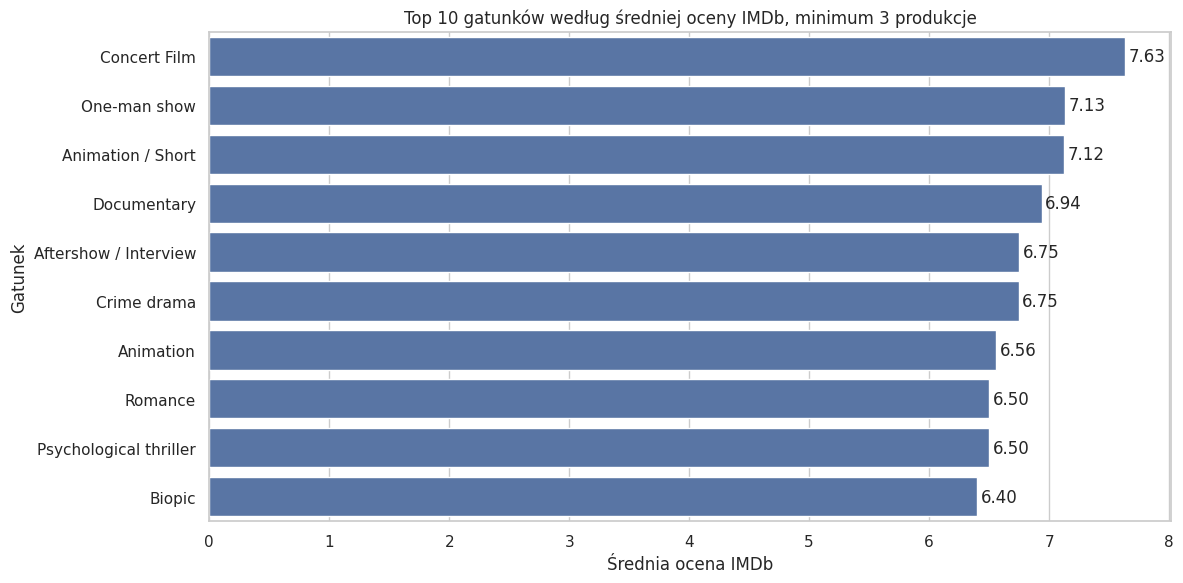

In [25]:
# Bardziej wiarygodna wersja: tylko gatunki z minimum 3 produkcjami.
genre_stats = data.groupby('Genre').agg(
    avg_score=('IMDB Score', 'mean'),
    movie_count=('Title', 'count')
)

genre_stats = genre_stats[genre_stats['movie_count'] >= 3]
top_10_genres_min3 = genre_stats.sort_values('avg_score', ascending=False).head(10)

display(top_10_genres_min3)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_10_genres_min3, x='avg_score', y=top_10_genres_min3.index)

plt.title('Top 10 gatunków według średniej oceny IMDb, minimum 3 produkcje')
plt.xlabel('Średnia ocena IMDb')
plt.ylabel('Gatunek')

for i, value in enumerate(top_10_genres_min3['avg_score']):
    ax.text(value + 0.03, i, f'{value:.2f}', va='center')

plt.tight_layout()
plt.show()


## 10. Top 20 najwyżej ocenianych produkcji

Na końcu pokazujemy ranking 20 najwyżej ocenianych produkcji w zbiorze danych.


In [26]:
# Wybór 20 najwyżej ocenianych produkcji
top_20_movies = (
    data[['IMDB Score', 'Title', 'Genre', 'year', 'Language']]
    .sort_values('IMDB Score', ascending=False)
    .head(20)
)

display(top_20_movies)


,IMDB Score,Title,Genre,year,Language
583,9.0,David Attenborough: A Life on Our Planet,Documentary,2020.0,English
582,8.6,Emicida: AmarElo - It's All For Yesterday,Documentary,2020.0,Portuguese
581,8.5,Springsteen on Broadway,One-man show,2018.0,English
580,8.4,Winter on Fire: Ukraine's Fight for Freedom,Documentary,2015.0,English/Ukranian/Russian
579,8.4,Taylor Swift: Reputation Stadium Tour,Concert Film,2018.0,English
578,8.4,Ben Platt: Live from Radio City Music Hall,Concert Film,2020.0,English
577,8.3,Dancing with the Birds,Documentary,2019.0,English
576,8.3,Cuba and the Cameraman,Documentary,2017.0,English
573,8.2,Klaus,Animation/Christmas/Comedy/Adventure,2019.0,English
571,8.2,13th,Documentary,2016.0,English


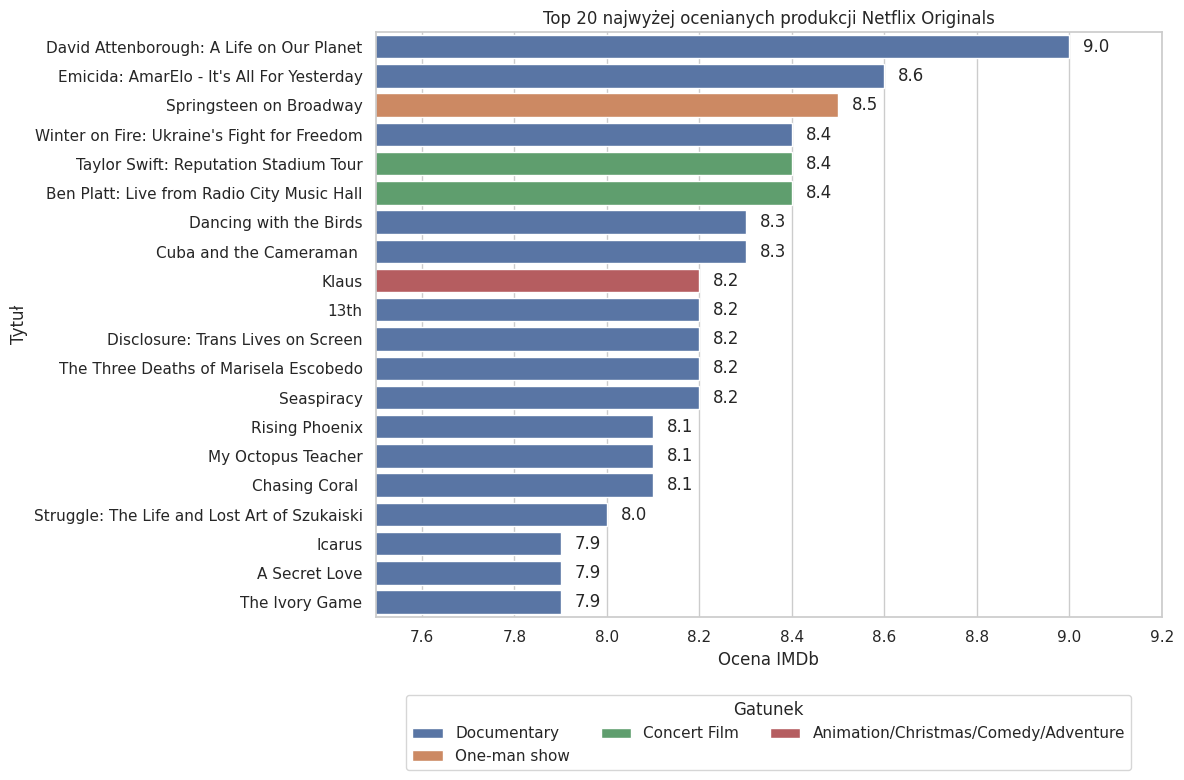

In [27]:
# Poziomy barplot jest czytelniejszy niż scatterplot, ponieważ pokazuje ranking tytułów.
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=top_20_movies,
    x='IMDB Score',
    y='Title',
    hue='Genre',
    dodge=False
)

plt.title('Top 20 najwyżej ocenianych produkcji Netflix Originals')
plt.xlabel('Ocena IMDb')
plt.ylabel('Tytuł')
plt.xlim(7.5, 9.2)

# Podpisanie wartości ocen przy słupkach
for i, value in enumerate(top_20_movies['IMDB Score']):
    ax.text(value + 0.03, i, f'{value:.1f}', va='center')

# Legenda pod wykresem, aby nie zasłaniała danych
plt.legend(
    title='Gatunek',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=3
)

plt.tight_layout()
plt.show()


## 11. Podsumowanie

Najważniejsze wnioski z analizy:

- Najczęściej występujące gatunki i języki pokazują strukturę katalogu Netflix Originals.
- Histogram czasu trwania pokazuje, że większość produkcji koncentruje się wokół typowej długości filmu.
- Rozkład ocen IMDb pozwala zauważyć, czy oceny są skupione wokół średniej, czy występują skrajne przypadki.
- Korelacja i wykres regresji pomagają sprawdzić, czy czas trwania ma związek z oceną.
- Analiza top gatunków i top filmów pokazuje, które typy produkcji osiągają najwyższe oceny.
